# Reverse Diffusion: Training-Free Score Estimation

- 신경망 없이 score $s(x,t) = \nabla_x \log p_t(x)$를 추정하는 방법 구현  
- Euler-Maruyama와 Probability Flow ODE(RK4)로 reverse diffusion을 비교

---

### Forward VP-SDE

$$dx = -\frac{1}{2}\beta(t)\,x\,dt + \sqrt{\beta(t)}\,dW$$

### Reverse SDE (Anderson, 1982)

$$dx = \left[-\frac{1}{2}\beta(t)\,x - \beta(t)\,s(x,t)\right]dt + \sqrt{\beta(t)}\,d\bar{W}$$

---

| Case | Score 추정 방법 |
|------|----------------|
| 0 | GMM 해석적 score (기준선) |
| 1 | Fokker-Planck PDE 수치적분 → $p_t$ |

---
## 공통: 데이터 & Forward SDE

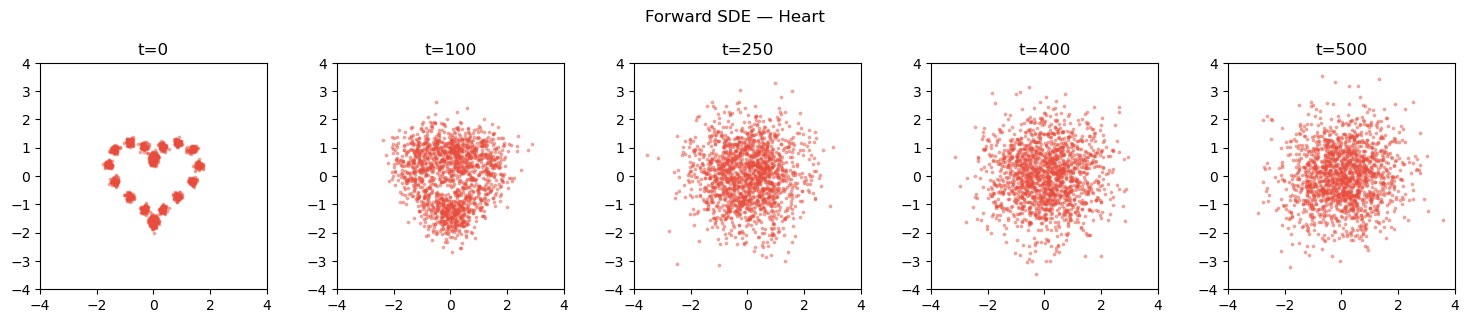

In [38]:
import numpy as np
import matplotlib.pyplot as plt
rng = np.random.default_rng(42)

def make_samples(means, std, n_per_mode):
    return np.vstack([mu + rng.standard_normal((n_per_mode, 2)) * std for mu in means])

# Grid
g = np.linspace(-2, 2, 3)
grid_means = np.array([[x, y] for y in g for x in g])

# Moons
th = np.linspace(0, np.pi, 300)
moon_means = np.vstack([
    np.c_[np.cos(th), np.sin(th)],
    np.c_[1 - np.cos(th), 1 - np.sin(th) - 0.5]
])

# Heart
t = np.linspace(0, 2*np.pi, 20, endpoint=False)
heart_means = np.c_[16*np.sin(t)**3,
                    13*np.cos(t)-5*np.cos(2*t)-2*np.cos(3*t)-np.cos(4*t)] / 10

datasets = {
    "grid":  make_samples(grid_means,  std=0.12, n_per_mode=150),
    "moons": make_samples(moon_means,  std=0.06, n_per_mode=1),
    "heart": make_samples(heart_means, std=0.07, n_per_mode=80),
}

# ── Noise schedule ────────────────────────────────────────────────────────────
T = 500
betas = np.linspace(1e-4, 0.02, T)
alpha_bar = np.cumprod(1 - betas)
sigma2_t  = 1 - alpha_bar

# ── Forward SDE ───────────────────────────────────────────────────────────────
SAVE_EVERY = 10

def forward_sde(x0):
    saved = {0: x0.copy()}
    x = x0.copy()
    for i, beta in enumerate(betas):
        x = x * (1 - 0.5*beta) + np.sqrt(beta) * rng.standard_normal(x.shape)
        t = i + 1
        if t % SAVE_EVERY == 0 or t == T:
            saved[t] = x.copy()
    return saved

fwd = {name: forward_sde(x0) for name, x0 in datasets.items()}

def get_refs(fwd_traj, t_idx):
    t_real = t_idx + 1
    ts = np.array(sorted(fwd_traj.keys()))
    return fwd_traj[ts[np.argmin(np.abs(ts - t_real))]]

# ── Heart forward 확인 ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(15, 3))
for ax, t in zip(axes, [0, 100, 250, 400, 500]):
    refs = get_refs(fwd["heart"], t-1) if t > 0 else fwd["heart"][0]
    ax.scatter(*refs.T, s=3, alpha=0.4, c="#e74c3c")
    ax.set_title(f"t={t}"); ax.set_xlim(-4,4); ax.set_ylim(-4,4); ax.set_aspect("equal")
fig.suptitle("Forward SDE — Heart", y=1.01); plt.tight_layout(); plt.show()

---
## 공통: Reverse Integrators

## Reverse SDE

$$dx = \left[-\frac{1}{2}\beta(t)\,x - \beta(t)\,s(x,t)\right]dt + \sqrt{\beta(t)}\,d\bar{W}$$

## Euler-Maruyama (SDE Solver)
$$x_{t-1} = x_t + \beta_t\!\left(-\tfrac{1}{2}x_t - s(x_t,t)\right)\Delta t + \sqrt{\beta_t\Delta t}\,\epsilon$$
---

In [39]:
def make_save_steps(n=6):
    """T를 n등분한 저장 스텝 (0과 T 포함)"""
    return tuple(sorted(set([0] + [round(T * i / (n - 1)) for i in range(n)])))

def reverse_euler(x_T, score_fn, save_steps=None):
    """Euler-Maruyama (stochastic SDE)"""
    if save_steps is None:
        save_steps = make_save_steps()
    save_set = set(save_steps)
    traj = {T: x_T.copy()}
    x = x_T.copy()
    for t_idx in reversed(range(T)):
        b = betas[t_idx]
        s = score_fn(x, t_idx)
        x = x + b * (-0.5 * x - s) + np.sqrt(b) * rng.standard_normal(x.shape)
        if t_idx in save_set:
            traj[t_idx] = x.copy()
    return traj

## Probability Flow ODE (RK4: ODE Solver)
### 핵심 목표
 
**노이즈를 없애되, $p_t$의 시간 변화는 동일하게 유지**
 
SDE와 ODE는 서로 다른 방정식이지만, **Fokker-Planck 수준에서 일치하면 같은 $p_t$를 만들어냄.**
 
---
 
### Step 1: Reverse SDE의 Fokker-Planck 방정식
 
Reverse SDE:
 
$$dx = \underbrace{\left[-\frac{1}{2}\beta x - \beta s\right]}_{f}\,dt + \underbrace{\sqrt{\beta}}_{g}\,d\bar{W}$$
 
이 SDE의 Fokker-Planck 방정식:
 
$$\frac{\partial p}{\partial t} = \underbrace{-\nabla\cdot(f\cdot p)}_{\text{drift 기여}} + \underbrace{\frac{1}{2}g^2\,\nabla^2 p}_{\text{노이즈 기여}}$$
 
---
 
### Step 2: ODE의 Fokker-Planck 방정식
 
ODE $\dfrac{dx}{dt} = \tilde{f}$의 Fokker-Planck:
 
$$\frac{\partial p}{\partial t} = -\nabla\cdot(\tilde{f}\cdot p)$$
 
노이즈가 없으니 두 번째 항이 없음.
 
---
 
### Step 3: 두 Fokker-Planck를 같게 놓기
 
$$-\nabla\cdot(\tilde{f}\cdot p) = -\nabla\cdot(f\cdot p) + \frac{1}{2}g^2\,\nabla^2 p$$
 
우변의 노이즈 항 $\dfrac{1}{2}g^2\,\nabla^2 p$을 $-\nabla\cdot(\cdot\, p)$ 꼴로 변환.
 
$$\frac{1}{2}g^2\,\nabla^2 p = \frac{1}{2}g^2\,\nabla\cdot(\nabla p)$$
 
여기서 $\nabla p = p \cdot \nabla\log p = p \cdot s$ 이므로:
 
$$= \nabla\cdot\!\left(\frac{1}{2}g^2\, s\cdot p\right)$$
 
따라서:
 
$$-\nabla\cdot(\tilde{f}\cdot p) = -\nabla\cdot(f\cdot p) + \nabla\cdot\!\left(\frac{1}{2}g^2\,s\cdot p\right) = -\nabla\cdot\!\left[\left(f - \frac{1}{2}g^2\,s\right)p\right]$$
 
$$\boxed{\tilde{f} = f - \frac{1}{2}g^2\,s}$$
 
---
 
### Step 4: 대입
 
$f = -\dfrac{1}{2}\beta x - \beta s$, $\quad g^2 = \beta$ 를 대입:
 
$$\tilde{f} = \left(-\frac{1}{2}\beta x - \beta s\right) - \frac{1}{2}\beta s = -\frac{1}{2}\beta x - \frac{1}{2}\beta s$$
 
최종 Probability Flow ODE:
 
$$\frac{dx}{dt} = -\frac{1}{2}\beta(t)\,x - \frac{1}{2}\beta(t)\,s(x,t)$$
 
---

In [40]:
def reverse_rk4(x_T, score_fn, save_steps=None):
    """
    Probability Flow ODE (deterministic), RK4 적분
    dx/dt = -β(t)/2 · x  -  β(t)/2 · s(x,t)
    """
    if save_steps is None:
        save_steps = make_save_steps()
    save_set = set(save_steps)
    traj = {T: x_T.copy()}
    x = x_T.copy()
    dt = -1.0  # 역방향이므로 음수

    def dxdt(x, t_idx):
        b = betas[max(t_idx, 0)]
        s = score_fn(x, max(t_idx, 0))
        return -0.5 * b * x - 0.5 * b * s

    for t_idx in reversed(range(T)):
        k1 = dxdt(x, t_idx)
        k2 = dxdt(x + 0.5 * dt * k1, t_idx)
        k3 = dxdt(x + 0.5 * dt * k2, t_idx)
        k4 = dxdt(x + dt * k3, t_idx - 1)
        x = x + (dt / 6) * (k1 + 2 * k2 + 2 * k3 + k4)
        if t_idx in save_set:
            traj[t_idx] = x.copy()
    return traj


def plot_steps(traj, steps=None, color="#3498db", title=""):
    """단일 방법의 스텝별 분포 시각화 (T→0 순서)"""
    if steps is None:
        steps = sorted(traj.keys(), reverse=True)  # T→0 방향
    fig, axes = plt.subplots(1, len(steps), figsize=(3 * len(steps), 3))
    for ax, t in zip(axes, steps):
        pts = traj.get(t, None)
        if pts is not None:
            ax.scatter(*pts.T, s=4, alpha=0.35, c=color)
        ax.set_xlim(-4, 4); ax.set_ylim(-4, 4); ax.set_aspect("equal")
        ax.set_title(f"t={t}")
    fig.suptitle(title, fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()

---
## Case 0 — GMM Exact Score + Euler vs RK4

VP-SDE의 marginal은 GMM을 유지:
$$p_t(x) = \frac{1}{K}\sum_k \mathcal{N}\!\left(x;\;\sqrt{\bar\alpha_t}\mu_k,\;\bar\alpha_t\sigma_k^2 + \sigma_t^2\right)$$

Score는 각 모드 score의 **사후확률 가중 합**:
$$s(x,t) = \sum_k w_k(x,t)\cdot\left(-\frac{x-\sqrt{\bar\alpha_t}\mu_k}{\bar\alpha_t\sigma_k^2+\sigma_t^2}\right), \qquad w_k = \frac{p_t^{(k)}(x)}{\sum_j p_t^{(j)}(x)}$$

이것이 신경망 없이 구할 수 있는 **이론상 완벽한 score**. Euler와 RK4를 비교하면 integrator 차이만 분리해서 볼 수 있다.

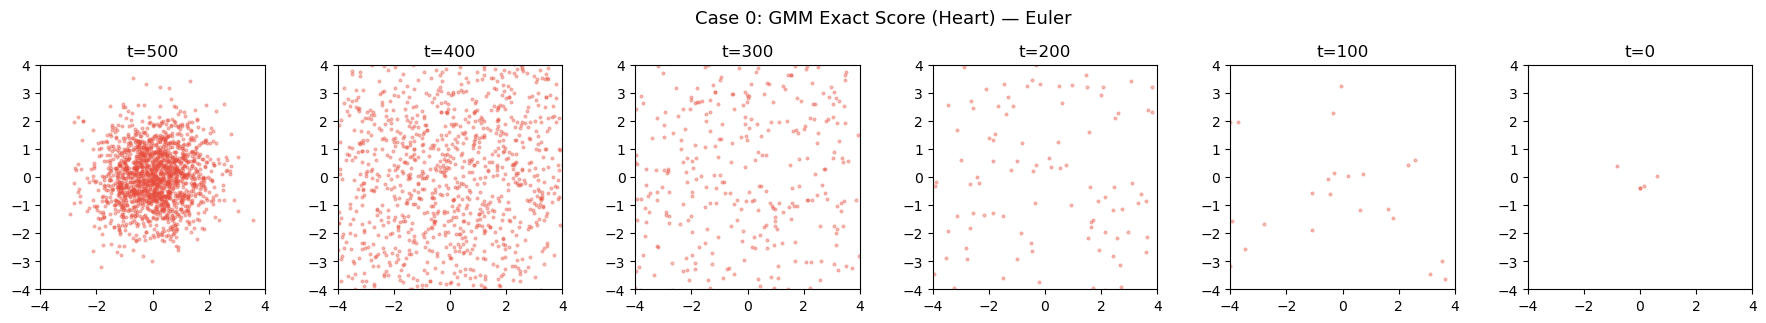

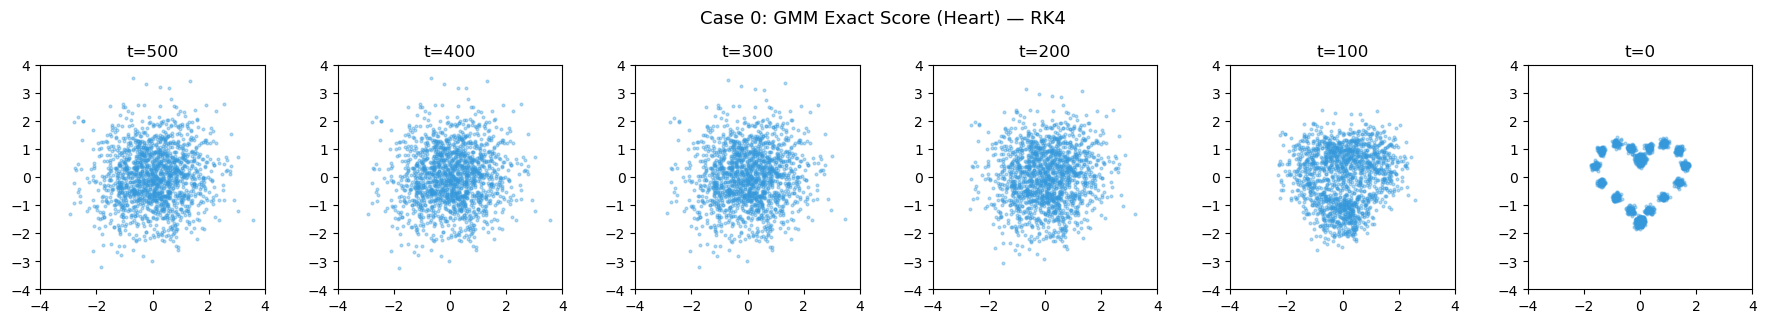

In [41]:
# Heart: GMM 모드들 (make_heart와 동일한 중심점)
_t = np.linspace(0, 2 * np.pi, 20, endpoint=False)
H_MEANS = (
    np.c_[
        16 * np.sin(_t) ** 3,
        13 * np.cos(_t) - 5 * np.cos(2 * _t) - 2 * np.cos(3 * _t) - np.cos(4 * _t),
    ]
    / 10
)  # (20,2)
H_VAR = 0.07**2


def gmm_score(x, t_idx):
    ab = alpha_bar[t_idx]
    s2 = sigma2_t[t_idx]
    mu_t = np.sqrt(ab) * H_MEANS  # (K,2)
    var_t = ab * H_VAR + s2  # scalar

    diff = x[:, None, :] - mu_t[None, :, :]  # (N,K,2)
    log_pk = -(diff**2).sum(-1) / (2 * var_t)
    log_pk -= log_pk.max(1, keepdims=True)
    wk = np.exp(log_pk)
    wk /= wk.sum(1, keepdims=True)

    score_k = -diff / var_t  # (N,K,2)
    return (wk[:, :, None] * score_k).sum(1)  # (N,2)


x_T = fwd["heart"][T].copy()
traj_e0 = reverse_euler(x_T, gmm_score)
traj_r0 = reverse_rk4(x_T, gmm_score)

plot_steps(traj_e0, title="Case 0: GMM Exact Score (Heart) — Euler", color="#e74c3c")
plot_steps(traj_r0, title="Case 0: GMM Exact Score (Heart) — RK4",   color="#3498db")